In [52]:
import numpy as np
import matplotlib.pyplot as plt
import opensimplex as os

from copy import deepcopy
from numba import jit
from time import time

In [53]:
size = (1080, 1920)

curr_field = np.zeros(size)
prev_field = None

In [54]:
@jit(nopython=True, fastmath=True)
def init(x, y): 
    x_, y_ = x / 10, y / 10
    return x + y

In [55]:
os.seed(int(time()))
scale = 20
seed = np.array([[int(4 * np.abs(os.noise2(scale * i / size[0], scale * j / size[1]))) 
                        for i in range(size[0])] for j in range(size[1])])

[]

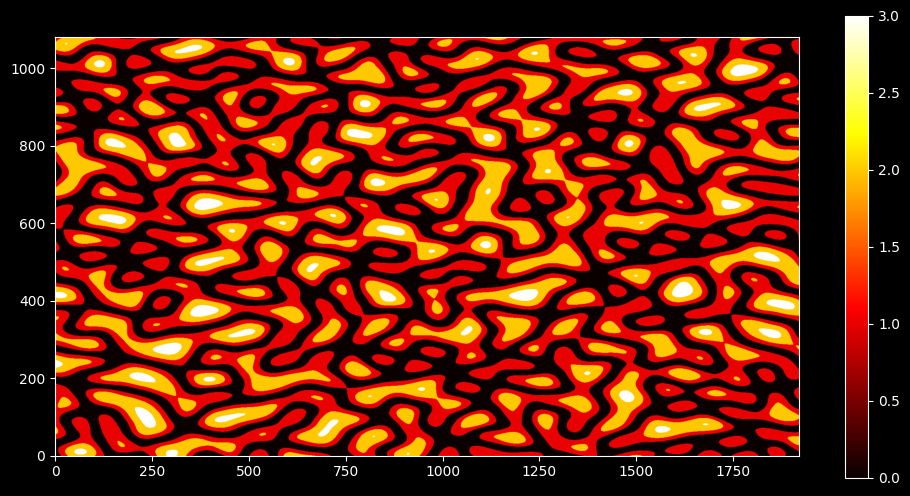

In [56]:
plt.figure(figsize=(12, 6))
plt.imshow(seed.T, origin='lower', cmap='hot')
plt.colorbar()
plt.plot()

In [57]:
@jit(nopython=True, fastmath=True)
def step(curr, prev, seed): 
    for i in range(size[0]):
        for j in range(size[1]):
            dx, dy = [(-1, 0), (1, 0), (0, -1), (0, 1)][seed[i, j]]

            curr[i, j] = prev[(i+dx)%size[0], (j+dy)%size[1]]

In [58]:
for i in range(size[0]):
    for j in range(size[1]):
        curr_field[i, j] = init(i, j)

In [59]:
curr_field = np.random.randint(1, 100, size)

In [68]:
for _ in range(100):
    prev_field = deepcopy(curr_field)
    step(curr_field, prev_field, seed)

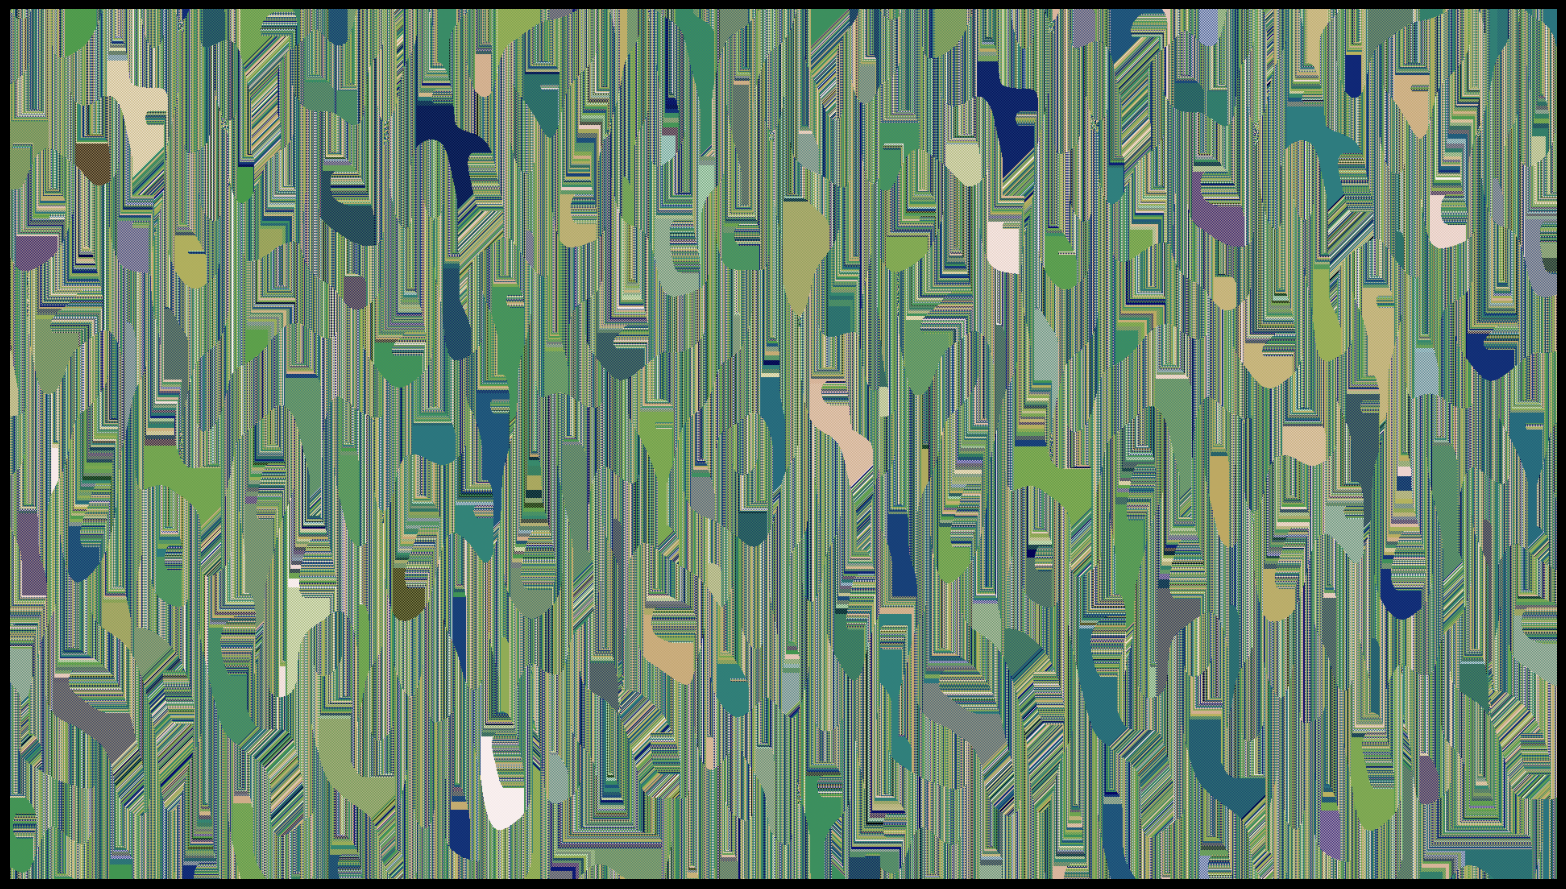

In [69]:
plt.figure(figsize=(16, 9))
plt.imshow(curr_field, origin='lower', cmap='gist_earth')
# plt.colorbar()
plt.axis('off')
plt.tight_layout()
plt.plot()
plt.savefig('outp/output.png')